# Notebook 1 Baseline Model Training
- Set up a FastAI training pipeline to establish a baseline model.

## Import Library

In [1]:
import pandas as pd
import numpy as np
import os
import random

# for visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# for fastai
from fastai.vision.all import *


In [2]:
# Allow full column width display in Pandas
pd.set_option('display.max_colwidth', None)

## Load Dataset

In [3]:
# load all files
for dirname, _,filenames in os.walk('/kaggle/input'):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))

/kaggle/input/competition-files/benchmark.ipynb
/kaggle/input/competition-files/train_labels.csv
/kaggle/input/competition-files/train_features.csv
/kaggle/input/competition-files/test_features.csv
/kaggle/input/competition-files/submission_format.csv
/kaggle/input/competition-files/train_features/ZJ003277.jpg
/kaggle/input/competition-files/train_features/ZJ002547.jpg
/kaggle/input/competition-files/train_features/ZJ000938.jpg
/kaggle/input/competition-files/train_features/ZJ005086.jpg
/kaggle/input/competition-files/train_features/ZJ010327.jpg
/kaggle/input/competition-files/test_features/ZJ020900.jpg
/kaggle/input/competition-files/test_features/ZJ017830.jpg
/kaggle/input/competition-files/test_features/ZJ016620.jpg
/kaggle/input/competition-files/test_features/ZJ018500.jpg
/kaggle/input/competition-files/test_features/ZJ020784.jpg


In [4]:
# Read train features
fpath = '/kaggle/input/competition-files/train_features.csv'
trn_fea = pd.read_csv(fpath)
trn_fea

,id,filepath,site
0,ZJ000000,train_features/ZJ000000.jpg,S0120
1,ZJ000001,train_features/ZJ000001.jpg,S0069
2,ZJ000002,train_features/ZJ000002.jpg,S0009
3,ZJ000003,train_features/ZJ000003.jpg,S0008
4,ZJ000004,train_features/ZJ000004.jpg,S0036
...,...,...,...
16483,ZJ016483,train_features/ZJ016483.jpg,S0093
16484,ZJ016484,train_features/ZJ016484.jpg,S0043
16485,ZJ016485,train_features/ZJ016485.jpg,S0089
16486,ZJ016486,train_features/ZJ016486.jpg,S0095


In [5]:
# read labels
fpath = '/kaggle/input/competition-files/train_labels.csv'
trn_label = pd.read_csv(fpath)
trn_label

,id,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ZJ000001,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,ZJ000002,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ZJ000003,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,ZJ000004,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
16483,ZJ016483,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
16484,ZJ016484,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
16485,ZJ016485,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
16486,ZJ016486,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
trn_label.describe(include='all')

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
count,16488,16488.000000,16488.000000,16488.000000,16488.000000,16488.000000,16488.000000,16488.000000,16488.000000
unique,16488,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ZJ016487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.150049,0.099527,0.134219,0.146955,0.059316,0.136705,0.151140,0.122089
std,NaN,0.357130,0.299377,0.340898,0.354072,0.236222,0.343547,0.358196,0.327398
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [7]:
# Check for columnns 
cols_all = list(trn_label.columns)
print(cols_all)

['id', 'antelope_duiker', 'bird', 'blank', 'civet_genet', 'hog', 'leopard', 'monkey_prosimian', 'rodent']


## Data Preprocessing
- Reformat or adapt the pipeline
- Handle missing or incorrect data if any

In [8]:
# Merge train features and labels on 'id'
df = pd.merge(trn_fea, trn_label, on='id')

# Preview merged dataframe
df.head(10)

,id,filepath,site,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ000000,train_features/ZJ000000.jpg,S0120,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ZJ000001,train_features/ZJ000001.jpg,S0069,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,ZJ000002,train_features/ZJ000002.jpg,S0009,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ZJ000003,train_features/ZJ000003.jpg,S0008,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,ZJ000004,train_features/ZJ000004.jpg,S0036,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,ZJ000005,train_features/ZJ000005.jpg,S0019,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,ZJ000006,train_features/ZJ000006.jpg,S0060,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7,ZJ000007,train_features/ZJ000007.jpg,S0047,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,ZJ000008,train_features/ZJ000008.jpg,S0083,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,ZJ000009,train_features/ZJ000009.jpg,S0059,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Simple check for any missing data
print('Missing data:', df.isna().sum().sum())

Missing data: 0


- Seems that each class is represented by its own column.
- We add each represented label for each.

In [10]:
# Convert one-hot columns into a single label column
classes = ['antelope_duiker', 'bird', 'blank', 'civet_genet', 'hog', 'leopard', 'monkey_prosimian', 'rodent']
df['label'] = df[classes].idxmax(axis=1)

# Check result for id and result
df[['id', 'label']].head(10)


,id,label
0,ZJ000000,bird
1,ZJ000001,monkey_prosimian
2,ZJ000002,bird
3,ZJ000003,monkey_prosimian
4,ZJ000004,leopard
5,ZJ000005,hog
6,ZJ000006,civet_genet
7,ZJ000007,antelope_duiker
8,ZJ000008,leopard
9,ZJ000009,bird


- Add the image file path to let the needed function locate the image more easily.

In [11]:
# Add full image path
df['image_path'] = '/kaggle/input/competition-files/' + df['filepath']

# Check path
df[['filepath', 'image_path']].head()

,filepath,image_path
0,train_features/ZJ000000.jpg,/kaggle/input/competition-files/train_features/ZJ000000.jpg
1,train_features/ZJ000001.jpg,/kaggle/input/competition-files/train_features/ZJ000001.jpg
2,train_features/ZJ000002.jpg,/kaggle/input/competition-files/train_features/ZJ000002.jpg
3,train_features/ZJ000003.jpg,/kaggle/input/competition-files/train_features/ZJ000003.jpg
4,train_features/ZJ000004.jpg,/kaggle/input/competition-files/train_features/ZJ000004.jpg


## Data Exploration
- Dataframe headers and descriptions
- Show class distribution
- Sample images
- Image size statistics

### Dataframe headers and descriptions

In [12]:
# Show the first 20 headers
df.head(20)

,id,filepath,site,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent,label,image_path
0,ZJ000000,train_features/ZJ000000.jpg,S0120,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,bird,/kaggle/input/competition-files/train_features/ZJ000000.jpg
1,ZJ000001,train_features/ZJ000001.jpg,S0069,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,monkey_prosimian,/kaggle/input/competition-files/train_features/ZJ000001.jpg
2,ZJ000002,train_features/ZJ000002.jpg,S0009,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,bird,/kaggle/input/competition-files/train_features/ZJ000002.jpg
3,ZJ000003,train_features/ZJ000003.jpg,S0008,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,monkey_prosimian,/kaggle/input/competition-files/train_features/ZJ000003.jpg
4,ZJ000004,train_features/ZJ000004.jpg,S0036,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,leopard,/kaggle/input/competition-files/train_features/ZJ000004.jpg
5,ZJ000005,train_features/ZJ000005.jpg,S0019,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,hog,/kaggle/input/competition-files/train_features/ZJ000005.jpg
6,ZJ000006,train_features/ZJ000006.jpg,S0060,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,civet_genet,/kaggle/input/competition-files/train_features/ZJ000006.jpg
7,ZJ000007,train_features/ZJ000007.jpg,S0047,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,antelope_duiker,/kaggle/input/competition-files/train_features/ZJ000007.jpg
8,ZJ000008,train_features/ZJ000008.jpg,S0083,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,leopard,/kaggle/input/competition-files/train_features/ZJ000008.jpg
9,ZJ000009,train_features/ZJ000009.jpg,S0059,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,bird,/kaggle/input/competition-files/train_features/ZJ000009.jpg


In [13]:
df.describe(include='all')

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,filepath,site,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent,label,image_path
count,16488,16488,16488,16488.000000,16488.000000,16488.000000,16488.000000,16488.000000,16488.000000,16488.000000,16488.000000,16488,16488
unique,16488,16488,148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,16488
top,ZJ016487,train_features/ZJ016487.jpg,S0060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,monkey_prosimian,/kaggle/input/competition-files/train_features/ZJ016487.jpg
freq,1,1,1132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2492,1
mean,NaN,NaN,NaN,0.150049,0.099527,0.134219,0.146955,0.059316,0.136705,0.151140,0.122089,NaN,NaN
std,NaN,NaN,NaN,0.357130,0.299377,0.340898,0.354072,0.236222,0.343547,0.358196,0.327398,NaN,NaN
min,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN


### Class distribution

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count images per class
class_counts = df['label'].value_counts()
class_counts

label
monkey_prosimian    2492
antelope_duiker     2474
civet_genet         2423
leopard             2254
blank               2213
rodent              2013
bird                1641
hog                  978
Name: count, dtype: int64

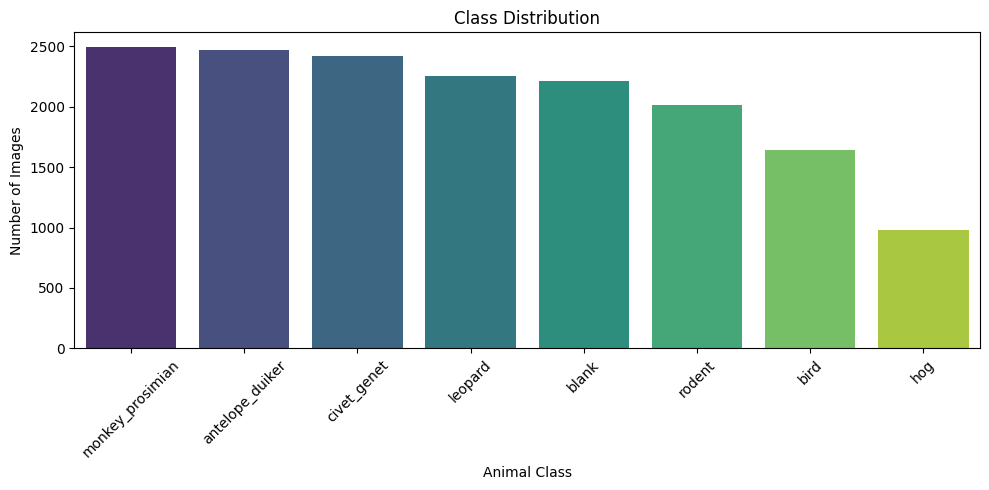

In [15]:
# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Distribution')
plt.xlabel('Animal Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sample images

In [16]:
# Pick 1 samples per label
samples_per_label = df.groupby('label').apply(lambda x: x.sample(1, random_state=1)).reset_index(drop=True)
samples_per_label

/tmp/ipykernel_19/2773496767.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples_per_label = df.groupby('label').apply(lambda x: x.sample(1, random_state=1)).reset_index(drop=True)


,id,filepath,site,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent,label,image_path
0,ZJ014433,train_features/ZJ014433.jpg,S0009,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,antelope_duiker,/kaggle/input/competition-files/train_features/ZJ014433.jpg
1,ZJ001622,train_features/ZJ001622.jpg,S0026,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,bird,/kaggle/input/competition-files/train_features/ZJ001622.jpg
2,ZJ010439,train_features/ZJ010439.jpg,S0047,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,blank,/kaggle/input/competition-files/train_features/ZJ010439.jpg
3,ZJ004182,train_features/ZJ004182.jpg,S0060,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,civet_genet,/kaggle/input/competition-files/train_features/ZJ004182.jpg
4,ZJ011902,train_features/ZJ011902.jpg,S0022,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,hog,/kaggle/input/competition-files/train_features/ZJ011902.jpg
5,ZJ014889,train_features/ZJ014889.jpg,S0038,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,leopard,/kaggle/input/competition-files/train_features/ZJ014889.jpg
6,ZJ005555,train_features/ZJ005555.jpg,S0019,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,monkey_prosimian,/kaggle/input/competition-files/train_features/ZJ005555.jpg
7,ZJ002381,train_features/ZJ002381.jpg,S0120,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,rodent,/kaggle/input/competition-files/train_features/ZJ002381.jpg


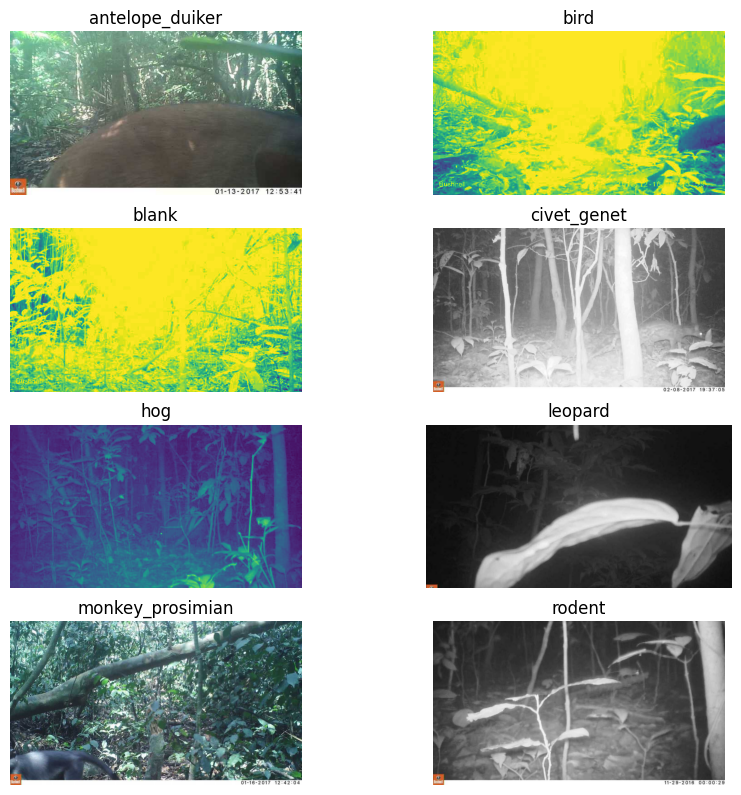

In [17]:
# Plot
num_classes = samples_per_label['label'].nunique()
plt.figure(figsize=(10, 2.5 * num_classes))

for idx, (_, row) in enumerate(samples_per_label.iterrows()):
    img = Image.open(row['image_path'])
    plt.subplot(num_classes, 2, idx + 1)
    plt.imshow(img)
    plt.title(row['label'])
    plt.axis('off')

plt.show()

### Image size statistics

In [18]:
# Get all image paths
all_imgs = get_image_files('/kaggle/input/competition-files/train_features')

# Create a dataframe of sizes
sizes = [PILImage.create(img).size for img in all_imgs[:500]]  # Sample first 500 for speed
size_df = pd.DataFrame(sizes, columns=['width', 'height'])

# Show basic stats
print(size_df.describe())

            width      height
count  500.000000  500.000000
mean   757.760000  426.430000
std    200.539809  108.094746
min    160.000000   95.000000
25%    640.000000  360.000000
50%    640.000000  360.000000
75%    960.000000  540.000000
max    960.000000  540.000000


## Save Baseline Model
- Export the trained model for Task 2

### Create a DataBlock

In [19]:
# Create a DataBlock
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader('image_path'),
    get_y=ColReader('label'),
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224),
)

In [20]:
# Create DataLoaders
dls = dblock.dataloaders(df, bs=64)

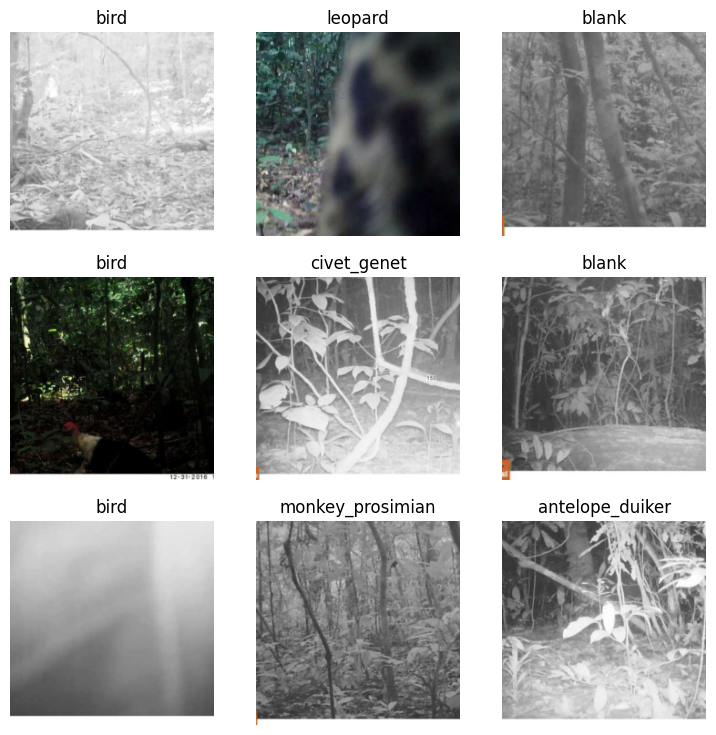

In [21]:
# Show sample batch
dls.show_batch(max_n=9)

### Train a Baseline Mode

In [22]:
learn = vision_learner(dls, resnet34, metrics=accuracy)
learn.fine_tune(5)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 173MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,1.781327,1.089095,0.603579,01:03


epoch,train_loss,valid_loss,accuracy,time
0,1.111343,0.752392,0.740067,00:48
1,0.781312,0.541346,0.812860,00:47
2,0.567010,0.461381,0.831968,00:47
3,0.388970,0.396380,0.872308,00:48
4,0.287712,0.389841,0.872915,00:49


In [23]:
# Check for validation set
len(learn.dls.valid.items)

3297

### Export the Model

In [24]:
learn.export('wildlife_baseline_v3.pkl')